<a href="https://colab.research.google.com/github/chaitanysaraswat/Advanced-Analytics-Using-Statistics/blob/main/lecture7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

In [ ]:
from scipy import stats
from scipy.stats import binom,poisson,norm,t

pmf-exactly

cdf-upto

1-cdf minimum more than

standard normal curve

operational normal curve

z=value-mean/std

norm.cdf(z,0,1)





In [ ]:
binom.pmf(50,80,.5)
1-binom.cdf(49,80,0.7)# 50 and above
norm.cdf(1.73)


np.float64(0.9581848623864051)

students t distribution:
- population std deviation is not known and sample std deviation is known
- necessarily is used when sample size is less than equal to 30
- t distribution has no constrain in calculation of norm
- normal distribution should be above sample size 30


In [ ]:
# 15 trips mean=15.3 sample size std=1.8 probability<=14
z=14-15.3/1.8
t.cdf(z,14)
norm.cdf(z)


np.float64(0.9999999810104375)

exponential distribution :
- this distribution is used model or prdeict time gap b/w two succesive events
- 365*24->200
- 200incident ->8760hr
- 1->8760/200=43.8hr/incident mean time b/w failure
- rate of failure =0.0228 incident/hours

situations wil be given interview and what we have to use as distribution

In [ ]:
from scipy.stats import expon
# Q
expon.cdf(100,scale=43.8)

np.float64(0.898032895521957)

In [ ]:
expon.cdf(1,scale=0.3)#what is probaility that you are disturbe after 1  hour by horn if scale means on  average
# exponential modelling time
# on average  johnson comes 30 times in a 45 days course 8 hours  what is probality  they will come today
45*8/30
expon.cdf(8,scale=12)
# 50 12 probality 0.7
#

np.float64(0.486582880967408)

# EDA (Exploratory Data anlaysis)
eda is to condition of data
* missing value (categorical dat use mode to fill data,
* data validation(inconsistency of data)



In [ ]:
df=pd.read_excel("/content/drive/MyDrive/My pitch/data1.xlsx")
df.head()

,Category
0,C
1,D
2,C
3,A
4,B


In [ ]:
df.isnull().sum()

,0
Category,80


In [ ]:
np.where(df.Category.isnull())

(array([  9,  11,  15,  32,  35,  38,  47,  48,  58,  59,  62,  64,  80,
         81,  82,  84,  95,  98, 122, 123, 140, 156, 161, 163, 164, 165,
        166, 167, 170, 174, 176, 177, 188, 192, 193, 212, 217, 223, 227,
        231, 237, 238, 246, 248, 250, 254, 257, 260, 267, 268, 269, 278,
        281, 287, 303, 328, 329, 333, 342, 345, 349, 357, 382, 384, 387,
        404, 406, 441, 445, 447, 451, 456, 459, 464, 471, 476, 477, 490,
        492, 494]),)

In [ ]:
80/df.shape[0]# mising values /rows df.shape will give row and column we are taking row by [0]

0.16

In [ ]:
from collections import Counter
Counter(df.Category).most_common() #find most common elements that are occuring

[('B', 193), ('A', 112), ('C', 101), ('D', 94)]

In [ ]:
df.Category.fillna('B',inplace=True)
df.isnull().sum()
df.Category=df.Category.fillna('B')

,0
Category,0


In [ ]:
df.Category.mode()# to find highest occurence

,Category
0,B


In [ ]:
df=pd.read_excel("/content/drive/MyDrive/My pitch/data1.xlsx")
df.head()

,Category
0,C
1,D
2,C
3,A
4,B


In [ ]:
df.Category.value_counts()

,count
Category,
B,113
A,112
C,101
D,94


In [ ]:
props=pd.DataFrame(df.Category.value_counts())

In [ ]:
props['proportion']=props['count']/sum(props['count'])

In [ ]:
random_values=np.random.choice(['A','B','C','D'],size=80,p=props.proportion)#ABCD IN 80 EMPTY VALUES IT WILL BE STORED IN PROPORTIONS TABLE
ind=np.where(df.Category.isnull())# IT WILL EXTRACT  NuLL VALUE INDICES
df.loc[ind[0],'Category']=random_values# IND[0] WILL GIVE ALL INDICES OF ROW AND PUSH RANDOM VALUES IN IT
df.Category.isnull().sum()

np.int64(0)

df.Quantity.fillna(df.Quantity.median) we use for quantitative data  

we use  median bcoz of outliers and if there is no outliers than also we use
median bcoz of skewness of data and data is not be symmetric


In [ ]:
df1=pd.read_excel("/content/drive/MyDrive/My pitch/data2.xlsx")
df1.head()

,Category,Continuous_Value
0,C,-4008.098297
1,D,-3887.888132
2,NaN,-3712.188312
3,C,-3416.823821
4,D,-5845.073897


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Category          850 non-null    object 
 1   Continuous_Value  880 non-null    float64
dtypes: float64(1), object(1)
memory usage: 15.8+ KB


In [ ]:
df1.Continuous_Value=df1.Continuous_Value.fillna(df1.Continuous_Value.median())

In [ ]:
df1.isnull().sum()

,0
Category,150
Continuous_Value,0


extreme values
* is depend upon subjectivity of th person

outlier:
 * will follow the rules

1 q1

2 q2 median

3 q3

4 IQR=q3-q1=130-70=60

5 upper fence/upper bound=q3+1.5*IQR=220

6 lower fence/upper bound=q1-1.5*IQR=70-90=-20 or 0

7 maximum value b/w q3 and uf

8 minimum value b/w q1 and lf

 upper fence and lower fence may not exist

9 outlier will be above 220

10 outlier will be above -20 to 0

whisker will always go upto maximumum value b/w q3 and upper fence

q2=median

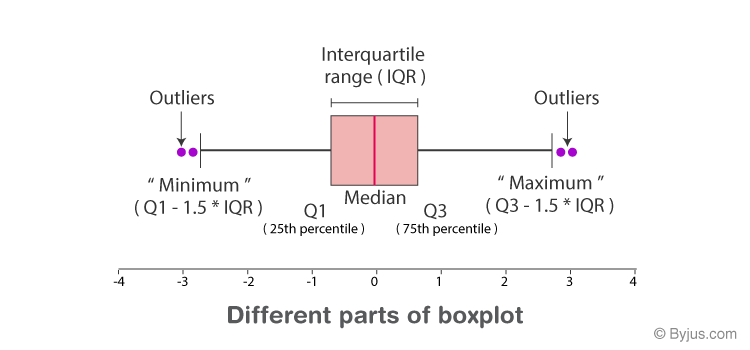


AFTER IMPORT OF DATA:
* CHECK DATATYPE

In [ ]:
# q1=4411.8
# q2/median =5030
# q3=5564
# iqr=1152.84
# whiskers,a=2697.30 ,7290.9
# n=1000

In [1]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

# Data Visualization
Barplot/barchart:
* this chart is used when the value on the x-axis categorical data
* mostly on y axis frequency
* different bars in chart will not touch eachother will of equal thickness
* becoz the category is different

<BarContainer object of 5 artists>

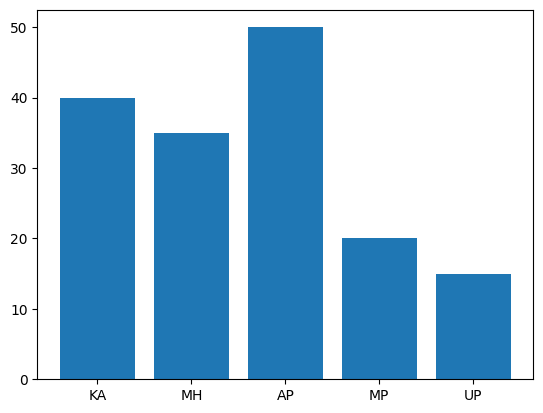

In [2]:
states=['KA','MH','AP','MP','UP']
counts=[40,35,50,20,15]
plt.bar(states,counts)

In [10]:

import numpy as np
import pandas as pd
df=pd.read_excel('/content/drive/MyDrive/My pitch/CDAC_DataBook.xlsx',sheet_name='ERPData')
df.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


<BarContainer object of 6 artists>

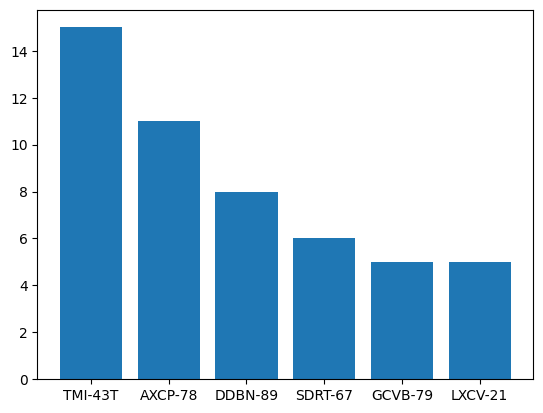

In [5]:
df1=df.MaterialID.value_counts()
plt.bar(df1.index,df1)# this one is for bar

<BarContainer object of 5 artists>

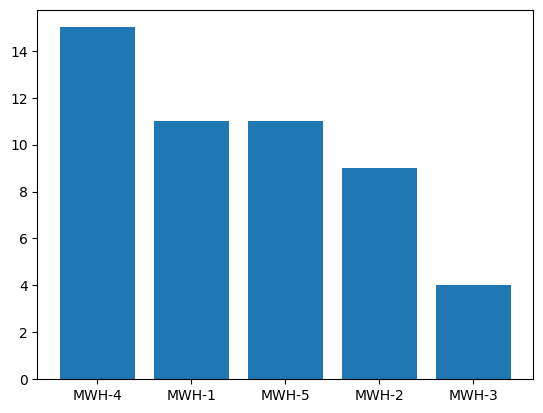

In [6]:
df1=df.Location.value_counts()
plt.bar(df1.index,df1)#using location

MaterialID
AXCP-78    898
DDBN-89    383
GCVB-79    182
LXCV-21    243
SDRT-67    294
TMI-43T    885
Name: Quantity, dtype: int64



<BarContainer object of 6 artists>

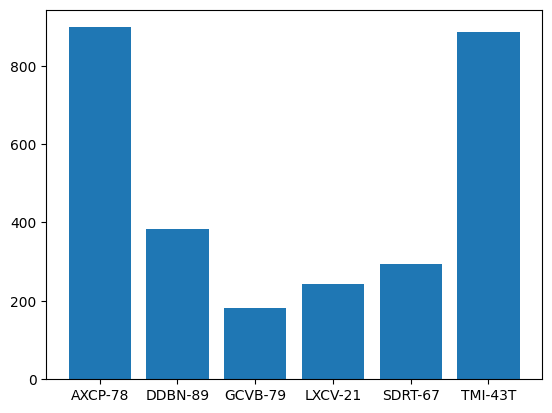

In [24]:
df1=df.groupby("MaterialID")
# print(df1.groups)
sum1=df1.Quantity.agg('sum')
print(sum1,end='\n\n')
plt.bar(sum1.index,sum1)

<Axes: >

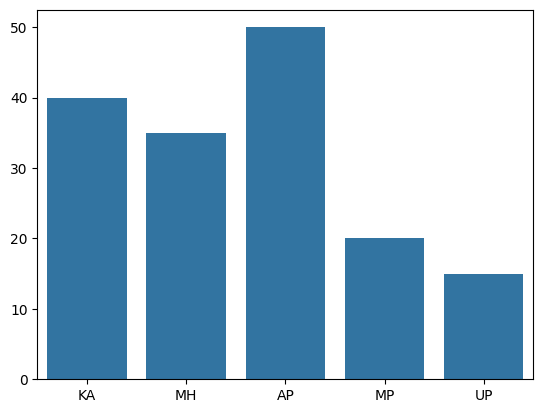

In [25]:
sns.barplot(x=states,y=counts)# this one is for seaborn

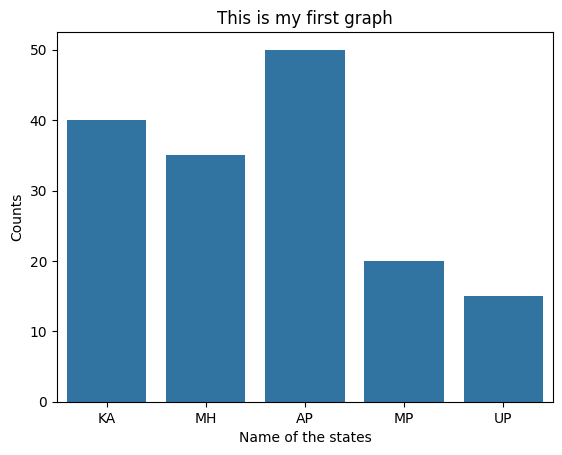

In [27]:
sns.barplot(x=states,y=counts)
plt.title('This is my first graph')
plt.xlabel("Name of the states")
plt.ylabel('Counts')
plt.show()

identify the probability distribution in the following scenarios

1. A manufacturing company inspects 25 products from a production line where each product can either be defective or non-defective. Find the probability of exactly 4 defective products.

2. A website receives an average of 18 customer complaints per day. Find the probability of receiving exactly 22 complaints tomorrow.poisson

3. The blood pressure readings of adults in a city follow a symmetric bell-shaped pattern around the mean. normal

4. A professor wants to estimate the average study hours of students using a sample of 10 students where the population standard deviation is unknown.student t

5. The time between two consecutive arrivals of customers at an ATM is being analyzed.expon

6. A basketball player has an 80% chance of scoring a free throw. Find the probability that the player scores exactly 7 baskets out of 10 attempts.binomial

7. The number of accidents occurring at a traffic signal per week is being studied.poisson

8. The weights of newborn babies in a large hospital are approximately symmetric and bell-shaped. normal

9. A medical researcher conducts an experiment on only 7 patients to estimate the average effectiveness of a treatment.

10. The waiting time before the next phone call arrives at a customer support center is being modeled.

11. An online advertisement is shown to 40 users. Each user either clicks or does not click the advertisement. Find the probability of exactly 12 clicks.

12. The number of power failures occurring in a city every month is being analyzed.

13. The annual salaries of employees in a very large company are approximately bell-shaped around the average salary.

14. A scientist takes a sample of 15 observations to estimate the population mean when the population variance is unknown.

15. The time until the next customer enters a supermarket is being studied.

In [28]:
df.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


In [31]:
df1=pd.crosstab(df.Location,df.MaterialID)
df1

MaterialID,AXCP-78,DDBN-89,GCVB-79,LXCV-21,SDRT-67,TMI-43T
Location,,,,,,
MWH-1,5,3,0,0,2,1
MWH-2,1,1,4,1,1,1
MWH-3,1,1,0,1,0,1
MWH-4,1,2,0,0,1,11
MWH-5,3,1,1,3,2,1


below is group bar chart two categorical( data one data inside other)

<Axes: xlabel='Location'>

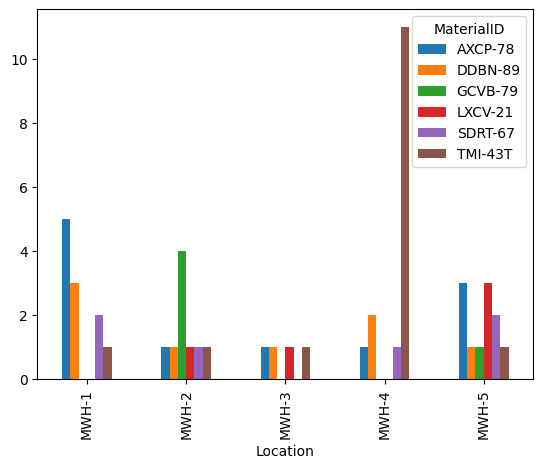

In [32]:
df1.plot(kind='bar')

In [34]:
df=pd.read_excel('/content/drive/MyDrive/My pitch/CDAC_DataBook.xlsx',sheet_name='nominal')
df.head()

,ses,write,math,prog
0,1,35,41,1
1,2,33,41,2
2,3,39,44,3
3,1,37,42,1
4,2,31,40,2


<Axes: xlabel='ses'>

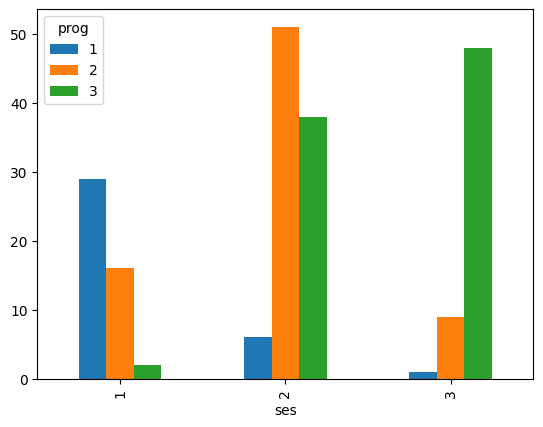

In [41]:
df1=pd.crosstab(df.ses,df.prog)
df1.plot(kind='bar')

when we  want to establish efect of categorical dat aon another categorical

data we make a group bar chart

boxplot is only made with continuous data

# Gender has any effect on salary  graph

{'whiskers': [<matplotlib.lines.Line2D at 0x7e6b41067dd0>,
 'caps': [<matplotlib.lines.Line2D at 0x7e6b407ec3b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e6b40fdaf60>,
 'medians': [<matplotlib.lines.Line2D at 0x7e6b407ec980>,
 'fliers': [<matplotlib.lines.Line2D at 0x7e6b407eccb0>,
 'means': []}

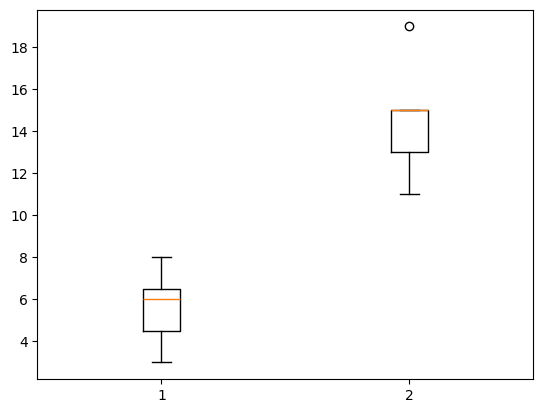

In [43]:
# effect of categorical data on continuous data
male_sal=[4,6,5,3,7,6,8]
female_sal=[11,15,13,19,15]
plt.boxplot([male_sal,female_sal])